### CG versus DLRA-CG
In this notebook, I compare using standard CG to find $X = \text{mat}(x)$ versus using the proposed DLRA-CG method. For a fair comparison, I implement CG manually

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from time import time
from utils.colors import C2
from utils.problem_setup import TestProblemsSetup
from utils.utils import progress_bar, disk_cache
from algorithms.cg_solvers import ConjugateGradient, DynamicalLowRankCG

SEED = 15

/home/elias/miniforge3/envs/fenics_env/lib/python3.9/site-packages/ufl/__init__.py:250: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Converged at iter 349 [rel_res=7.08e-11]0


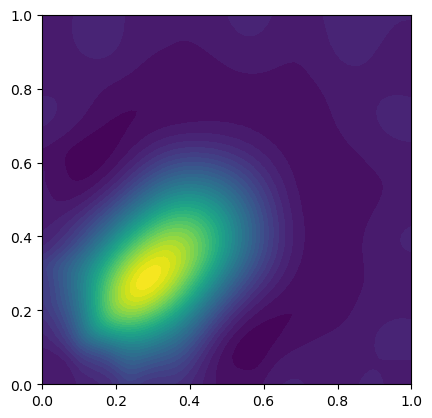

In [3]:
# Setup and train an rSVD solver
pid = 'I'
setup = TestProblemsSetup(n=64)
p = setup.problem_setup(
    params=setup.problem_params[pid],
    compute_weights=True,
    k=25
)

# Solve using standard CG
solver_cg = ConjugateGradient(p['rsvd'])
x_hat = solver_cg.solve(
    y=p['y'],
    w=p['w'],
    lambda_=(1e-4)**2,
    rtol=1e-10,
    max_iter=1000,
    verbose=True,
    #max_rank=1
)

from fenics import Function, plot
f_hat = Function(p['V_h'])
f_hat.vector()[:] = x_hat
plot(f_hat)

In [3]:
@disk_cache('../../results/CG_versus_DLRA')
def experiment(
    N_range: np.ndarray,
    rtol: float,
    repeat: int = 1,
    pid: str = 'I',
    k: int = 25,
) -> pd.DataFrame:

    record = []

    step, n_steps = 1, len(N_range) * repeat
    for r in range(repeat):
        for N in N_range:
            results = {'N': N} 
            n = round(np.sqrt(N))

            progress_bar(step, n_steps, end_text=f' [{N=:,}]')
            step += 1

            # Setup and train an rSVD solver
            setup = TestProblemsSetup(n=n)
            p = setup.problem_setup(
                params=setup.problem_params[pid],
                compute_weights=True,
                k=k
            )

            # Solve using standard CG
            solver_cg = ConjugateGradient(p['rsvd'])
            t0 = time()
            solver_cg.solve(
                y=p['y'],
                w=p['w'],
                lambda_=(1e-4)**2,
                rtol=rtol,
                max_iter=1000,
                verbose=False
            )
            results['time-CG'] = time() - t0
            results['niter-CG'] = solver_cg.niter

            # Solve using DLRA-CG
            solver_dlr = DynamicalLowRankCG(p['rsvd'])
            t0 = time()
            solver_dlr.solve(
                y=p['y'],
                w=p['w'],
                lambda_=(1e-4)**2,
                rtol=rtol,
                max_iter=1000,
                max_rank=1,
                verbose=False
            )
            results['time-DLRA-CG'] = time() - t0
            results['niter-DLRA-CG'] = solver_dlr.niter

            record.append(results)
        
    return pd.DataFrame(record)

        

In [4]:
N_range = np.linspace(1_000, 500_000, 11, dtype=int)

params = [
    {'N_range': N_range, 'rtol': 1e-8, 'repeat': 5},
    {'N_range': N_range, 'rtol': 1e-12, 'repeat': 5},
]

results = {p['rtol']: experiment(**p) for p in params}

In [5]:
def compute_stats(df: pd.DataFrame):
    return (
        df.groupby("N")
        .agg({
            "time-CG": "median",
            "time-DLRA-CG": "median",
            "niter-CG": "mean",
            "niter-DLRA-CG": "mean",
        })
        .reset_index()
    )

stats = {rtol: compute_stats(df) for rtol, df in results.items()}

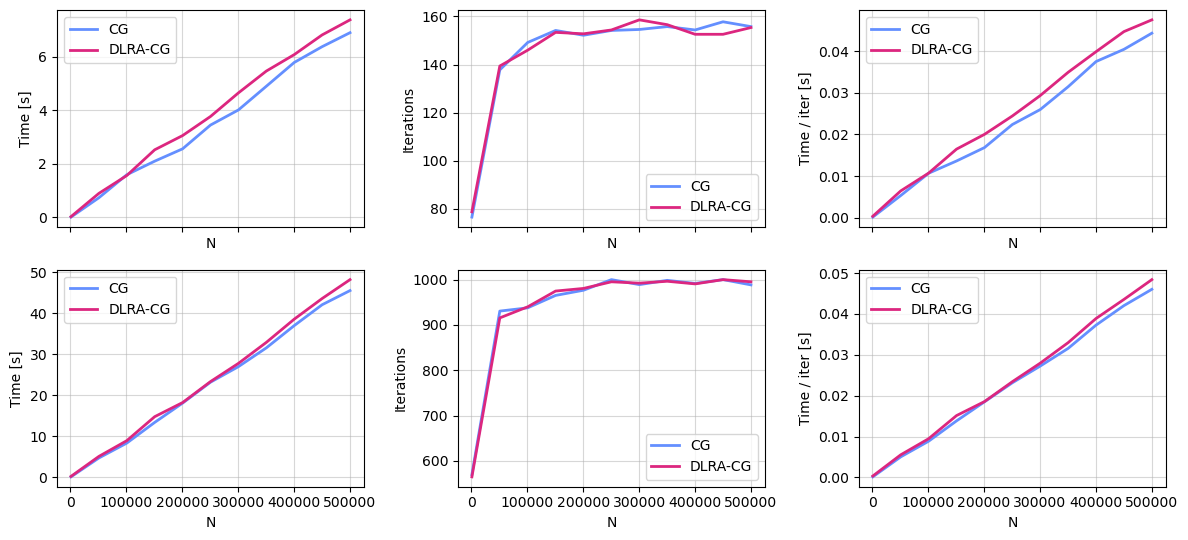

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(12, 5.5), sharex=True)

for i, (rtol, df) in enumerate(stats.items()):
    ax1, ax2, ax3 = axes[i, :]

    ax1.plot(df.N, df['time-CG'], label='CG', c=C2[0], lw=2)
    ax1.plot(df.N, df['time-DLRA-CG'], label='DLRA-CG', c=C2[1], lw=2)

    ax2.plot(df.N, df['niter-CG'], label='CG', c=C2[0], lw=2)
    ax2.plot(df.N, df['niter-DLRA-CG'], label='DLRA-CG', c=C2[1], lw=2)

    ax3.plot(df.N, df['time-CG'] / df['niter-CG'], label='CG', c=C2[0], lw=2)
    ax3.plot(df.N, df['time-DLRA-CG'] / df['niter-DLRA-CG'], label='DLRA-CG', c=C2[1], lw=2)

    ax1.set_ylabel('Time [s]')
    ax2.set_ylabel('Iterations')
    ax3.set_ylabel('Time / iter [s]')

for ax in axes.flat:
    ax.legend()
    ax.set_xlabel('N')
    ax.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

In [12]:
A = np.random.rand(10_000,10_000)

In [13]:
%timeit np.linalg.norm(A, 'fro')

40.1 ms ± 8.31 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [14]:
%timeit np.sum(A * A)

450 ms ± 172 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [15]:
%timeit np.dot(A.ravel(), A.ravel())

36.5 ms ± 4.17 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [ ]:
def frobenius_squared(A):
    a = A.ravel()
    return np.dot(a, a)

%timeit frobenius(A)

35 ms ± 542 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)
